<a href="https://colab.research.google.com/github/JeffersonRodrigues9/Projetos-em-Machine-Learning/blob/main/opecv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Imagem original com marcação ---


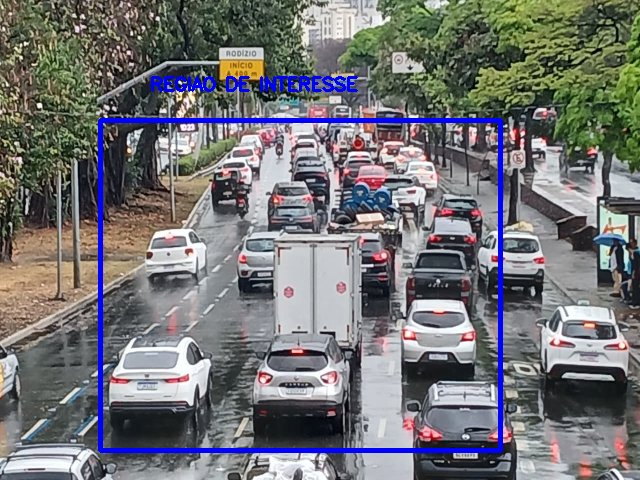


--- Imagem em escala de cinza ---


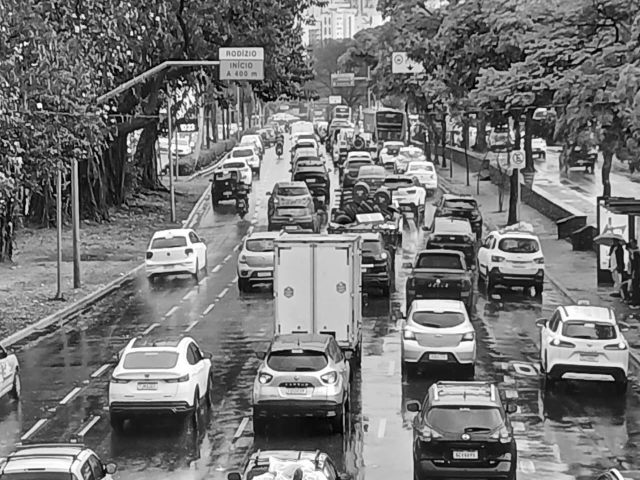

In [58]:
# LEITURA E MODIFICAÇÃO DE IMAGEM ESTÁTICA
import cv2
from google.colab.patches import cv2_imshow # Exclusivo para renderizar imagens no google Colab

# 1. Carregar a imagem
imagem = cv2.imread('cenario.jpg')

# 2. Redimensionar para um tamanho padrão de exibição
imagem = cv2.resize(imagem,(640, 480))

# 3. Converter para escala de cinza (simplificação matemática de matriz)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# Desenhar um caixa de marcação manual em uma área da imagem
#Parâmetros: cv2.rectangle(imagem, (x_inicio, y_inicio), (x_fim, y_fim), (B, G, R) espessura
cv2.rectangle(imagem, (100, 120), (500, 450), (255, 0, 0),3)
cv2.putText(imagem, "REGIAO DE INTERESSE", (150, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# 4. Exibir os resultados na tela
print('--- Imagem original com marcação ---')
cv2_imshow(imagem)

print("\n--- Imagem em escala de cinza ---")
cv2_imshow(imagem_cinza)

In [11]:
!pip install easyocr opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 23.0 MB/s eta 0:00:00


[SISTEMA] Escaneando caracteres da placa ...

[SUCESSO] Texto extraído: BRA2E19

--- Recorte da placa ---


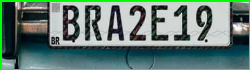


--- Resultado final ---


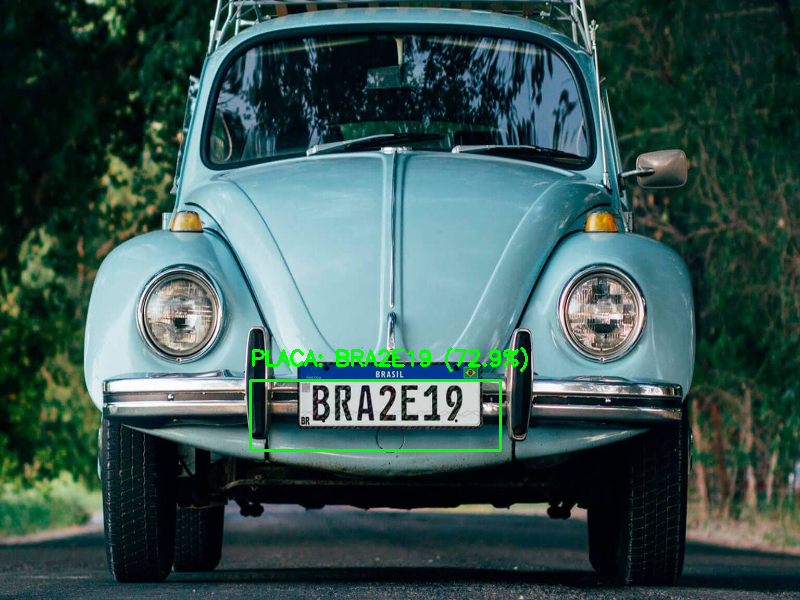

In [65]:
# LEITURA AUTOMÁTICA DE PLACAS

import cv2
import easyocr
from google.colab.patches import cv2_imshow

# 1. Inicializar OCR
leitor_ocr = easyocr.Reader(['pt'])

# 2. Carregar imagem
imagem_veiculo = cv2.imread('carro.jpg')

# Redimensionar
imagem_veiculo = cv2.resize(imagem_veiculo, (800, 600))

# 3. Converter para cinza
imagem_cinza = cv2.cvtColor(imagem_veiculo, cv2.COLOR_BGR2GRAY)

# Coordenadas da placa
x_ini, x_fim = 250, 500
y_ini, y_fim = 380, 450

# Recorte da placa
placa_recortada_cinza = imagem_cinza[y_ini:y_fim, x_ini:x_fim]
placa_recortada_colorida = imagem_veiculo[y_ini:y_fim, x_ini:x_fim]

# 4. OCR
print("[SISTEMA] Escaneando caracteres da placa ...")

resultados_ocr = leitor_ocr.readtext(placa_recortada_cinza)

# 5. Verificar resultado
if len(resultados_ocr) > 0:

    texto_placa = resultados_ocr[0][1].upper().replace(" ", "")
    confianca = resultados_ocr[0][2] * 100

    # Desenhar retângulo
    cv2.rectangle(
        imagem_veiculo,
        (x_ini, y_ini),
        (x_fim, y_fim),
        (0, 255, 0),
        2
    )

    # Inserir texto
    cv2.putText(
        imagem_veiculo,
        f"PLACA: {texto_placa} ({confianca:.1f}%)",
        (x_ini, y_ini - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    print(f"\n[SUCESSO] Texto extraído: {texto_placa}")

else:
    print("\n[ALERTA] A IA não conseguiu ler a placa.")
    texto_placa = "NÃO DETECTADA"

# 6. Mostrar imagens
print("\n--- Recorte da placa ---")
cv2_imshow(placa_recortada_colorida)

print("\n--- Resultado final ---")
cv2_imshow(imagem_veiculo)